## **Prática de Visualização de Dados**

#### Autor: Tony Esaú de Oliveira - Universidade Federal do Cariri (UFCA)

##### **Descrição:** essa é a primeira prática de *Visualização de Dados* da trilha do Curso de Mineração de Dados da Universidade de Illinois. A prática consiste em fazer uma visualização do Conjunto de Dados *GisTemp V4* da NASA (*GISS Surface Temperature Analysis*), que consiste num conjunto de temperaturas anomálicas em relação a média anual, bem como a própria média anual (dezembro a janeiro), de 1880 até 2025.

---

### **1. Descrição do Conjunto de Dados**

##### 1.1) Conteúdo do dataset

O dataset apresenta valores médios globais organizados em três escalas temporais:

* Mensal;
* Sazonal;
* Anual.

Os dados cobrem o período de 1880 até o presente. 

**Obs.:** os valores representam **anomalias de temperatura**, e não temperaturas absolutas.

##### 1.2) Anomalias de temperatura

Uma anomalia corresponde à diferença entre a temperatura observada em um período e uma média de referência (baseline), geralmente calculada a partir de um período climatológico padrão.

Exemplos:

* 0,00 °C: temperatura igual à média de referência;
* +1,20 °C: temperatura 1,20 °C acima da média;
* −0,50 °C: temperatura 0,50 °C abaixo da média.


##### 1.3) Estrutura do arquivo

Cada linha do arquivo corresponde a um ano. As colunas incluem meses, estações do ano e médias anuais. Um formato típico é:

| Coluna    | Descrição                                                |
| --------- | -------------------------------------------------------- |
| Year      | Ano                                                      |
| Jan a Dec | Anomalias mensais                                        |
| DJF       | Dezembro–Janeiro–Fevereiro (inverno no hemisfério norte) |
| MAM       | Março–Abril–Maio (primavera no hemisfério norte)         |
| JJA       | Junho–Julho–Agosto (verão no hemisfério norte)           |
| SON       | Setembro–Outubro–Novembro (outono no hemisfério norte)   |
| J-D       | Média anual de janeiro a dezembro                        |
| D-N       | Média de dezembro a novembro do ano seguinte             |
| METEO     | Média meteorológica anual                                |

Todos os valores estão expressos em graus Celsius (°C).

##### 1.4) Aplicações

Este dataset é utilizado para:

* Análise de tendências de aquecimento global;
* Comparação de períodos históricos;
* Estudos estatísticos e modelagem climática;
* Visualização de séries temporais.

Exemplo de interpretação

* Se o valor da coluna J-D para determinado ano for +1,45 °C, isso indica que a temperatura média global daquele ano foi 1,45 °C acima da média de referência.

---

### **2. Importação e Tratamento**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### 2.1) Importando o Conjunto de Dados 

In [7]:
dados_Gistemp = pd.read_csv('Gistemp.csv')

Vamos verificar se a leitura ocorreu corretamente imprimindo o *head*:

In [8]:
dados_Gistemp.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.10,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.18,-0.18,***,***,-0.13,-0.17,-0.21
1,1881,-0.20,-0.15,0.03,0.04,0.05,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09,-.10,-.18,0.04,-0.08,-0.19
2,1882,0.15,0.13,0.04,-0.17,-0.15,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.36,-0.12,-.09,.07,-0.09,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.18,-0.17,-0.08,-0.07,-0.14,-0.21,-0.11,-0.23,-0.11,-0.18,-.20,-.34,-0.16,-0.10,-0.19
4,1884,-0.13,-0.08,-0.36,-0.41,-0.34,-0.36,-0.30,-0.27,-0.27,-0.25,-0.34,-0.31,-0.29,-.27,-.11,-0.37,-0.31,-0.29


##### 2.2) Reduzindo o Conjunto de Dados

Para essa visualização vamos usar apenas as anomalias mensais e média anual (`J-D`).

In [9]:
dados_Gistemp = dados_Gistemp.drop(columns=['D-N', 'DJF', 'MAM', 'JJA', 'SON'])

Vamos olhar novamente os dados:

In [10]:
dados_Gistemp.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D
0,1880,-0.19,-0.25,-0.10,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.18,-0.18
1,1881,-0.20,-0.15,0.03,0.04,0.05,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09
2,1882,0.15,0.13,0.04,-0.17,-0.15,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.36,-0.12
3,1883,-0.30,-0.37,-0.13,-0.18,-0.17,-0.08,-0.07,-0.14,-0.21,-0.11,-0.23,-0.11,-0.18
4,1884,-0.13,-0.08,-0.36,-0.41,-0.34,-0.36,-0.30,-0.27,-0.27,-0.25,-0.34,-0.31,-0.29


---

### **3. Visualização - Plotagem**

##### 3.1) Gráfico das Médias Anuais

Primeiramente, vamos fazer uma plotagem da médias anuais.

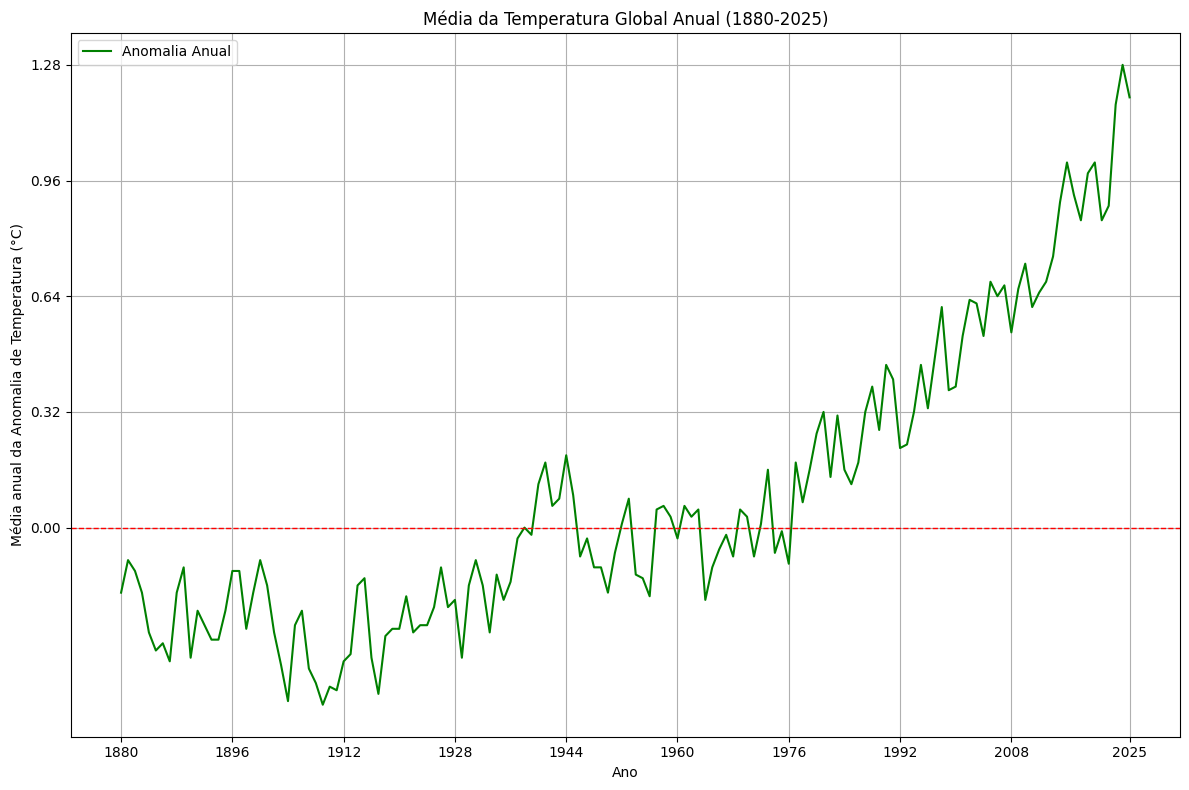

In [28]:
fig = plt.figure(figsize=(12,8))

plt.plot(dados_Gistemp['Year'], dados_Gistemp['J-D'], label = 'Anomalia Anual', color = 'green', linestyle = '-')

plt.title('Média da Temperatura Global Anual (1880-2025)')
plt.xlabel('Ano')
plt.ylabel('Média anual da Anomalia de Temperatura (°C)')

plt.legend()

indices = np.linspace(0, dados_Gistemp.shape[0] - 1, 10)

plt.xticks(dados_Gistemp['Year'].iloc[indices])

plt.axhline(y = 0, color='red', linestyle='--', linewidth=1)

indices = np.linspace(0, dados_Gistemp['J-D'].max(), 5)
plt.yticks(list(indices))
plt.grid()
plt.tight_layout()

plt.show()

Podemos ver qual foi a temperatura média máxima nesse período:

In [26]:
idx = dados_Gistemp['J-D'].idxmax()
print("Ano com maior anomalia:", dados_Gistemp.loc[idx, 'Year'], "com anomalia de", dados_Gistemp.loc[idx, 'J-D'], "°C.")


Ano com maior anomalia: 2024 com anomalia de 1.28 °C.


Vamos anotar no gráfico:

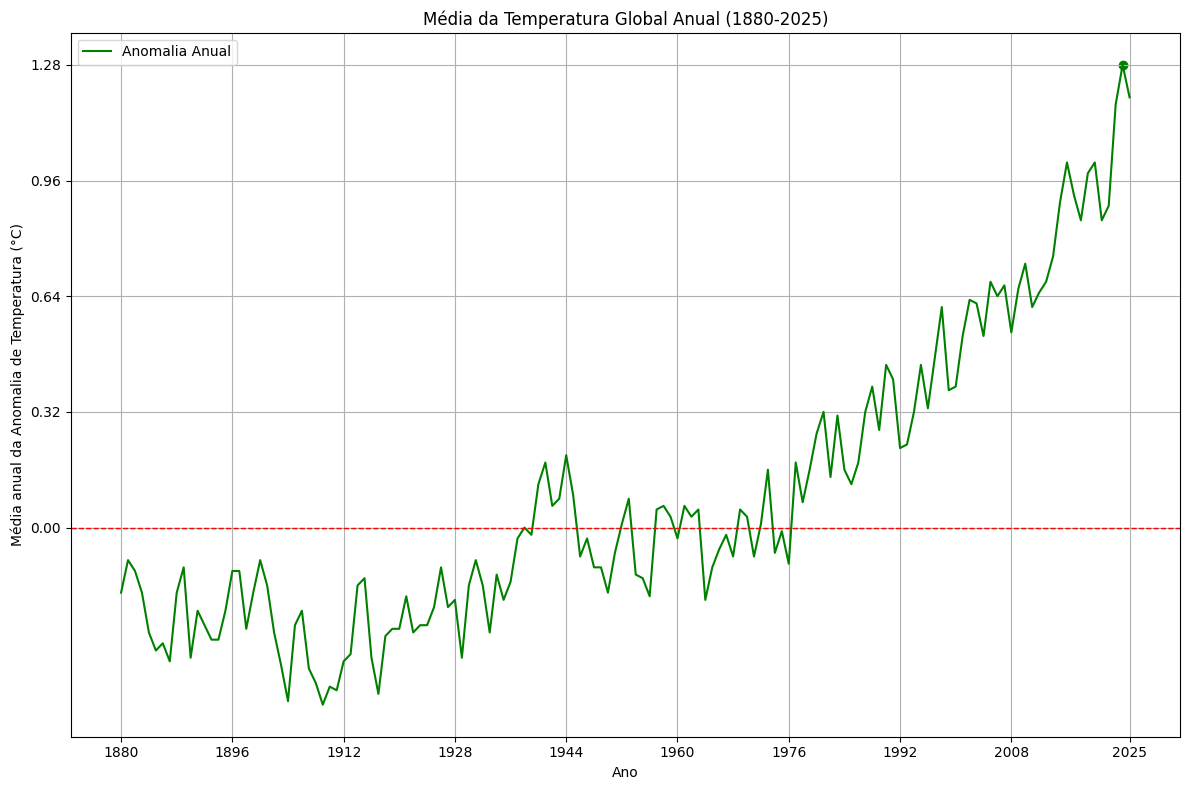

In [ ]:
fig = plt.figure(figsize=(12,8))

plt.plot(dados_Gistemp['Year'], dados_Gistemp['J-D'], label = 'Anomalia Anual', color = 'green', linestyle = '-')

plt.title('Média da Temperatura Global Anual (1880-2025)')
plt.xlabel('Ano')
plt.ylabel('Média anual da Anomalia de Temperatura (°C)')

plt.legend()

plt.grid()

# Ano mais quente.
idx_max = dados_Gistemp['J-D'].idxmax()
ano_max = dados_Gistemp.loc[idx_max, 'Year']
valor_max = dados_Gistemp.loc[idx_max, 'J-D']
plt.scatter(ano_max, valor_max, color='green')

indices = np.linspace(0, dados_Gistemp.shape[0] - 1, 10)

plt.xticks(dados_Gistemp['Year'].iloc[indices])

plt.axhline(y = 0, color='red', linestyle='--', linewidth=1)

indices = np.linspace(0, dados_Gistemp['J-D'].max(), 5)
plt.yticks(list(indices))
plt.tight_layout()

plt.show()

Agora para ver uma suavização do gráfico, faremos uma média movel simples. A seguir faço uma introdução rápida do que é média móvel:

* **Média móvel**: a média móvel é a média de um conjunto de valores em uma janela que se desloca ao longo do tempo. Ela é usada para suavizar oscilações e destacar tendências.

Exemplo:

* Série: 2, 4, 6, 8, 10  

Média móvel de 3 termos:

- (2 + 4 + 6) / 3 = 4  
- (4 + 6 + 8) / 3 = 6  
- (6 + 8 + 10) / 3 = 8

* Série da Média Movel: 2, 4, 4, 6, 8


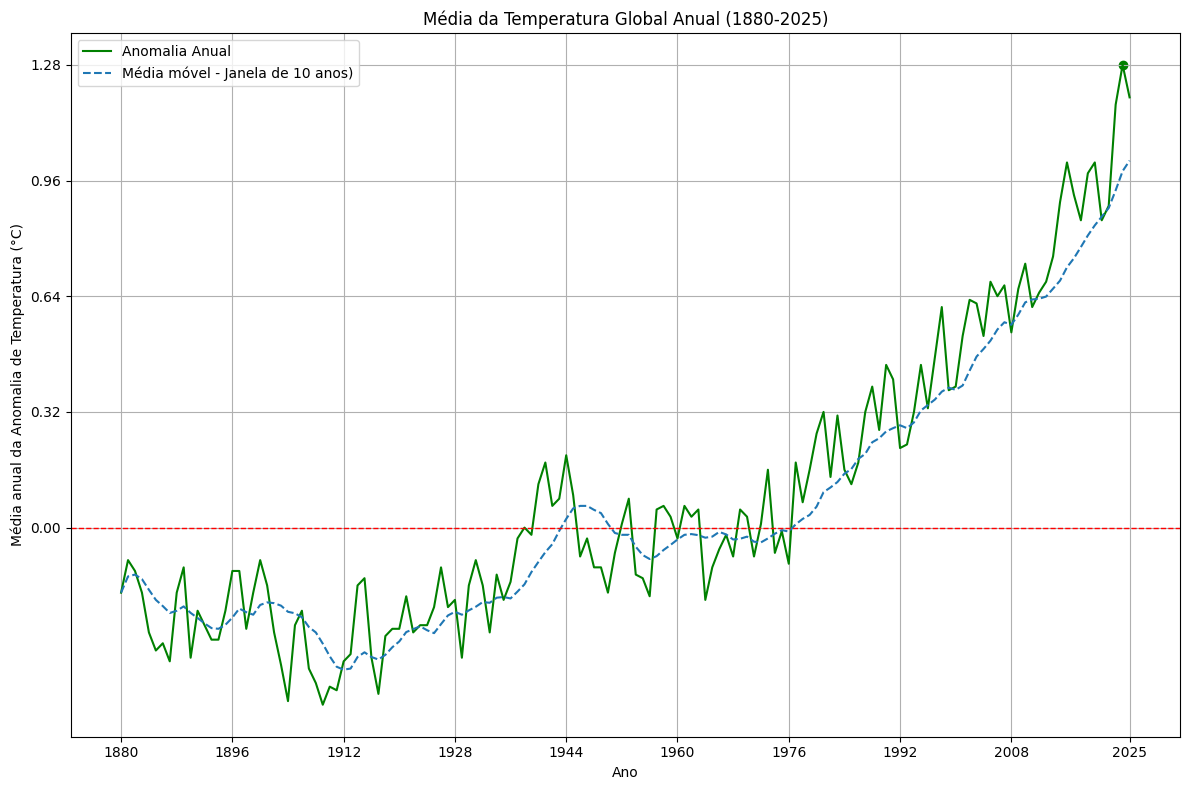

In [33]:
fig = plt.figure(figsize=(12,8))

plt.plot(dados_Gistemp['Year'], dados_Gistemp['J-D'], label = 'Anomalia Anual', color = 'green', linestyle = '-')

plt.title('Média da Temperatura Global Anual (1880-2025)')
plt.xlabel('Ano')
plt.ylabel('Média anual da Anomalia de Temperatura (°C)')

plt.grid()

# Ano mais quente.
idx_max = dados_Gistemp['J-D'].idxmax()
ano_max = dados_Gistemp.loc[idx_max, 'Year']
valor_max = dados_Gistemp.loc[idx_max, 'J-D']
plt.scatter(ano_max, valor_max, color='green')

# Calcula a média móvel padrão com janela de 10 anos.
dados_Gistemp['media_movel_10'] = dados_Gistemp['J-D'].rolling(window=10).mean()

# Preenche manualmente os NaN iniciais.
for i in range(9):
    dados_Gistemp.loc[i, 'media_movel_10'] = dados_Gistemp.loc[:i, 'J-D'].mean()

#plotagem da média móvel.
plt.plot(dados_Gistemp['Year'], dados_Gistemp['media_movel_10'], linestyle='--', label='Média móvel - Janela de 10 anos)')

indices = np.linspace(0, dados_Gistemp.shape[0] - 1, 10)
plt.xticks(dados_Gistemp['Year'].iloc[indices])
plt.axhline(y = 0, color='red', linestyle='--', linewidth=1)
indices = np.linspace(0, dados_Gistemp['J-D'].max(), 5)
plt.yticks(list(indices))

plt.tight_layout()
plt.legend()

plt.show()

Agora vamos apenas melhorar alguns aspectos visuais do gráfico:

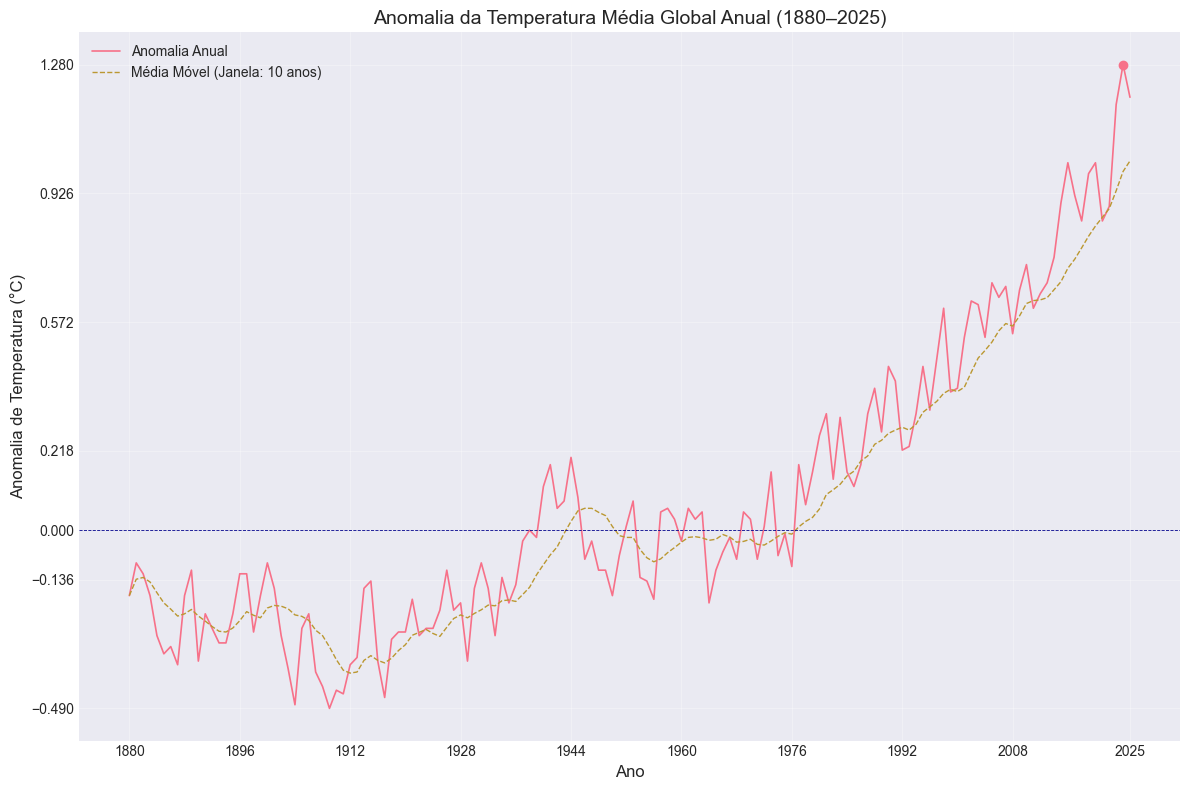

In [98]:
fig = plt.figure(figsize=(12,8))

plt.plot(dados_Gistemp['Year'], dados_Gistemp['J-D'],
         label='Anomalia Anual',
         linewidth=1.2)

plt.title('Anomalia da Temperatura Média Global Anual (1880–2025)', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Anomalia de Temperatura (°C)', fontsize=12)

plt.grid(alpha=0.3)

idx_max = dados_Gistemp['J-D'].idxmax()
ano_max = dados_Gistemp.loc[idx_max, 'Year']
valor_max = dados_Gistemp.loc[idx_max, 'J-D']
plt.scatter(ano_max, valor_max, zorder=5)

dados_Gistemp['media_movel_10'] = dados_Gistemp['J-D'].rolling(window=10).mean()
for i in range(9):
    dados_Gistemp.loc[i, 'media_movel_10'] = dados_Gistemp.loc[:i, 'J-D'].mean()

plt.plot(dados_Gistemp['Year'], dados_Gistemp['media_movel_10'],
         linestyle='--',
         linewidth=1,
         label='Média Móvel (Janela: 10 anos)')

plt.axhline(y=0, linestyle='--', linewidth=0.6, color='darkblue')

indices = np.linspace(0, dados_Gistemp.shape[0] - 1, 10, dtype=int)
plt.xticks(dados_Gistemp['Year'].iloc[indices], rotation=0)

y_min = dados_Gistemp['J-D'].min()
y_max = dados_Gistemp['J-D'].max()
ticks = np.linspace(y_min, y_max, 6)
ticks = np.unique(np.append(ticks, 0))
plt.yticks(ticks)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


##### 3.2) Gráfico de Barras com Cor Gradiente

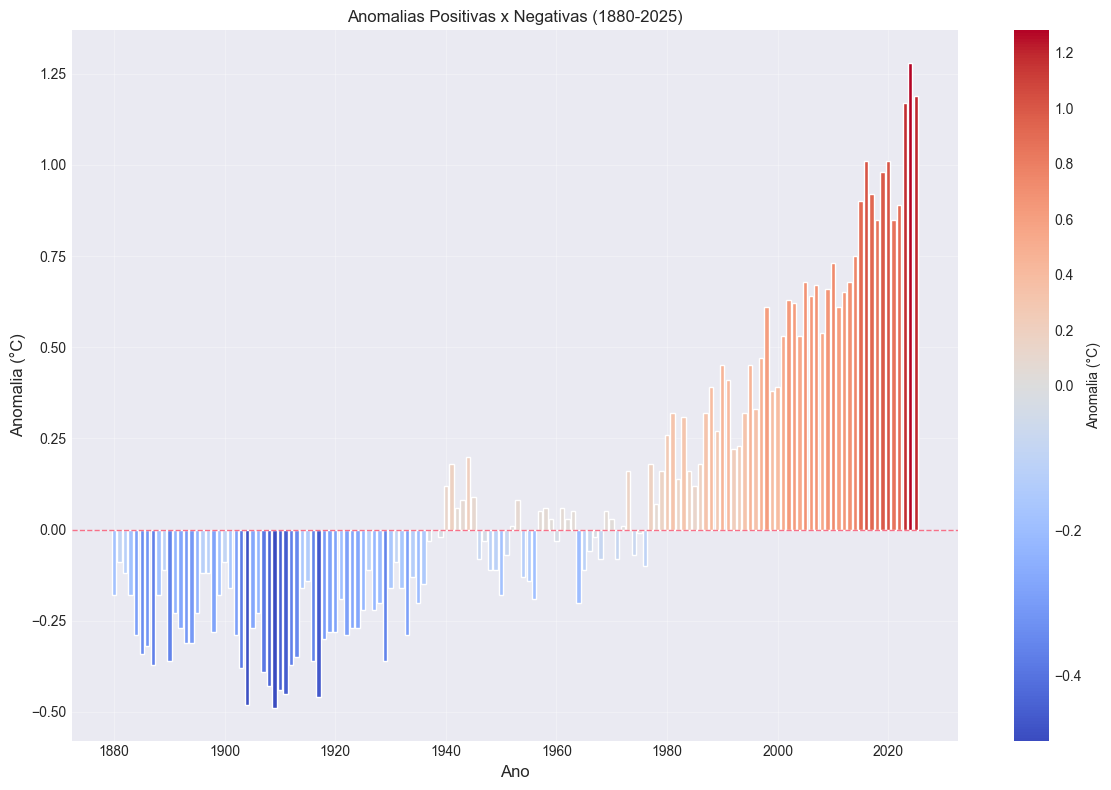

In [100]:
import matplotlib.cm as cm # Módulo de colormaps, ou seja, paletas de cores.
import matplotlib.colors as mcolors # Fornece ferramentas para normalizar valores e mapear para cores.

fig, ax = plt.subplots(figsize=(12,8))

# TwoSlopeNorm: cria uma normalização com dois pontos: valores abaixo e acima de um centro.
norma_cor = mcolors.TwoSlopeNorm(vmin=dados_Gistemp['J-D'].min(),
                            vcenter=0,
                            vmax=dados_Gistemp['J-D'].max())

# coolwarm é um colormap que vai de azul (frio) a vermelho (quente).
# norm(dados_Gistemp['J-D']) normaliza os valores de anomalia para [0,1] levando em conta vcenter=0.
# 'cores' vai ser um array de cores correspondentes a cada valor de 'J-D'.
cores = cm.coolwarm(norma_cor(dados_Gistemp['J-D']))

ax.bar(dados_Gistemp['Year'], dados_Gistemp['J-D'], color=cores)

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_title('Anomalias Positivas x Negativas (1880-2025)', fontsize=12)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Anomalia (°C)', fontsize=12)
ax.grid(alpha=0.3)

# ScalarMappable cria um objeto para gerar barra de cores (colorbar) baseada na normalização.
# set_array([]) é necessário pra criar a colorbar sem dados extras.
# fig.colorbar adiciona a legenda de cores à direita do gráfico.
barra_referencia = cm.ScalarMappable(cmap='coolwarm', norm=norma_cor)
barra_referencia.set_array([])
fig.colorbar(barra_referencia, ax=ax, label='Anomalia (°C)')

plt.tight_layout()
plt.show()


##### 3.3) Mapa de Calor

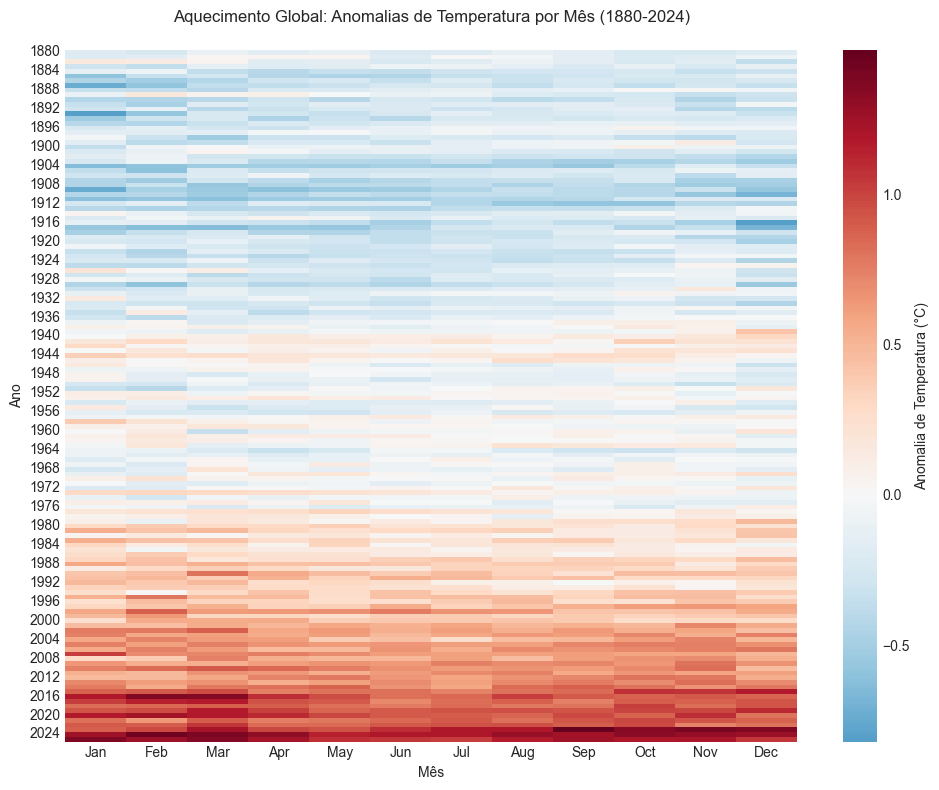

In [99]:
import seaborn as sns

# Filtrando as colunas de interesse.
meses = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
mapa_calor = dados_Gistemp[['Year'] + meses]

# Definir o ano como índice, para usar o Seaborn.
mapa_calor = mapa_calor.set_index('Year')

# Configurar o visual do gráfico.
plt.figure(figsize=(10,8))
sns.heatmap(mapa_calor, 
            cmap='RdBu_r',   # Cores: Azul (frio) para Vermelho (quente).
            center=0,        # Garante que o branco seja o ponto neutro (zero).
            annot=False,     # Mude para True se quiser ver os números em cada quadrado.
            linewidths=0.002,  
            linecolor='gray',
            cbar_kws={'label': 'Anomalia de Temperatura (°C)'})

plt.title('Aquecimento Global: Anomalias de Temperatura por Mês (1880-2024)', fontsize=12, pad=20)
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.tight_layout()

plt.show() 

##### 3.4) Fazendo a Visualização Final

A visualização final proposta é uma apresentação em *Subplots* (ou *grids*) de conteúdos, em que em cima há um gráfico que ocupa dois espaços da matriz de *plot* e em baixo há uma linha com dois *subplots*, que serão preenchidos com os outros dois gráficos.

C:\Users\tonye\AppData\Local\Temp\ipykernel_14208\3339080343.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.96])


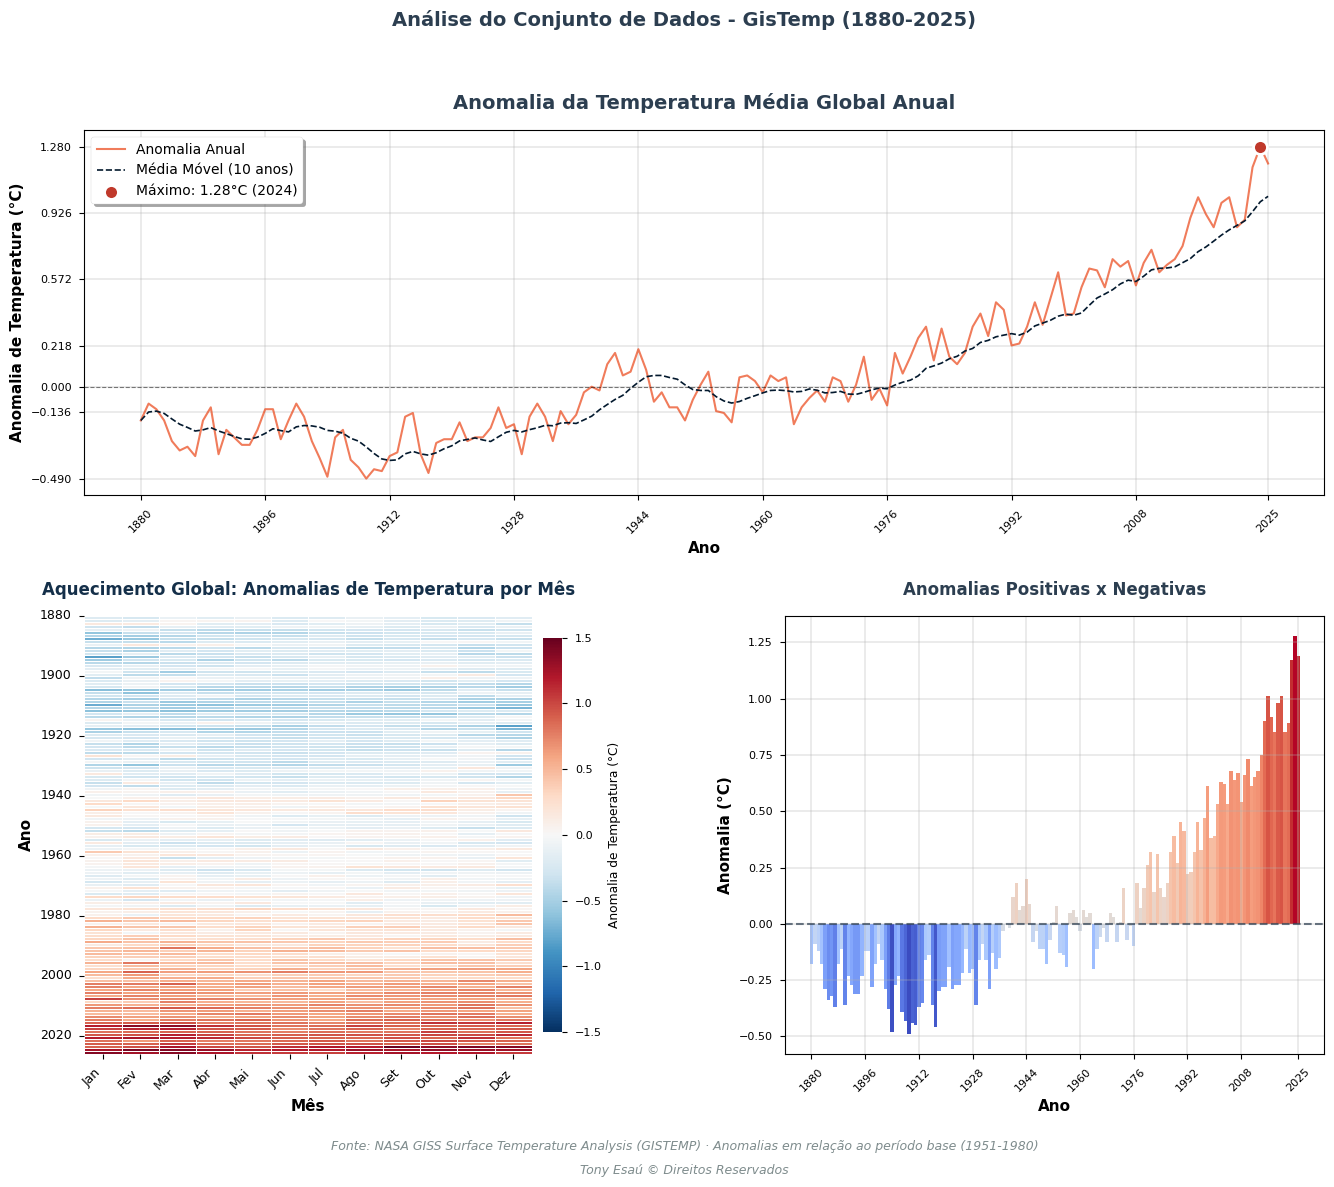

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plt.style.use("seaborn-v0_8-paper")

# Preparar dados para o heatmap.
meses = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
mapa_calor = dados_Gistemp[['Year'] + meses].copy()
mapa_calor = mapa_calor.set_index('Year')

# Calcular média móvel para o gráfico de linha.
dados_Gistemp['media_movel_10'] = dados_Gistemp['J-D'].rolling(window=10).mean()
for i in range(9):
    dados_Gistemp.loc[i, 'media_movel_10'] = dados_Gistemp.loc[:i, 'J-D'].mean()

# Criar figura com GridSpec para layout personalizado.
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], hspace=0.3, wspace=0.3)

# ========== GRÁFICO 1: LINHA - Anomalia Anual (ocupa as duas colunas superiores) ==========
ax1 = fig.add_subplot(gs[0, :])

# Plotar linha de anomalia.
ax1.plot(dados_Gistemp['Year'], dados_Gistemp['J-D'],
         label='Anomalia Anual',
         linewidth=1.5,
         color="#EA4416",
         alpha=0.7)

# Plotar média móvel.
ax1.plot(dados_Gistemp['Year'], dados_Gistemp['media_movel_10'],
         linestyle='--',
         linewidth=1.2,
         label='Média Móvel (10 anos)',
         color="#03192E")

# Marcar valor máximo
idx_max = dados_Gistemp['J-D'].idxmax()
ano_max = dados_Gistemp.loc[idx_max, 'Year']
valor_max = dados_Gistemp.loc[idx_max, 'J-D']
ax1.scatter(ano_max, valor_max, 
           s=100, 
           color='#C0392B', 
           zorder=5,
           edgecolor='white',
           linewidth=2,
           label=f'Máximo: {valor_max:.2f}°C ({int(ano_max)})')

# Linha de referência zero
ax1.axhline(y=0, linestyle='--', linewidth=0.8, color="#000000", alpha=0.5)

ax1.set_title('Anomalia da Temperatura Média Global Anual', 
              fontsize=14, 
              weight='bold',
              color='#2C3E50',
              pad=15)
ax1.set_xlabel('Ano', fontsize=11, weight='bold')
ax1.set_ylabel('Anomalia de Temperatura (°C)', fontsize=11, weight='bold')
ax1.grid(alpha=0.3, linestyle='-', linewidth=1.2)

# Ajustar ticks do eixo X
indices = np.linspace(0, dados_Gistemp.shape[0] - 1, 10, dtype=int)
ax1.set_xticks(dados_Gistemp['Year'].iloc[indices])
ax1.set_xticklabels(dados_Gistemp['Year'].iloc[indices], rotation=45)

# Ajustar ticks do eixo Y
y_min = dados_Gistemp['J-D'].min()
y_max = dados_Gistemp['J-D'].max()
ticks = np.linspace(y_min, y_max, 6)
ticks = np.unique(np.append(ticks, 0))
ax1.set_yticks(ticks)

ax1.legend(frameon=True, 
          loc='upper left', 
          fontsize=10,
          fancybox=True,
          shadow=True)

# ========== GRÁFICO 2: HEATMAP (inferior esquerdo) ==========
ax2 = fig.add_subplot(gs[1, 0])

sns.heatmap(mapa_calor, 
            cmap='RdBu_r',
            center=0,
            annot=False,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={
                'label': 'Anomalia de Temperatura (°C)',
                'shrink': 0.9,
                'pad': 0.02
            },
            vmin=-1.5,
            vmax=1.5,
            ax=ax2)

ax2.set_title('Aquecimento Global: Anomalias de Temperatura por Mês', 
              fontsize=12, 
              weight='bold',
              pad=15,
              color="#142F49")

ax2.set_xlabel('Mês', fontsize=11, weight='bold')
ax2.set_ylabel('Ano', fontsize=11, weight='bold')

# Melhorar os ticks do eixo Y.
anos = mapa_calor.index
intervalo = 20  # Intervalo maior para o gráfico menor.
indices_anos = range(0, len(anos), intervalo)
ax2.set_yticks(indices_anos)
ax2.set_yticklabels([anos[i] for i in indices_anos], rotation=0, fontsize=9)

# Labels dos meses em português.
ax2.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                     'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'], 
                    rotation=45, ha='right', fontsize=9)

# ========== GRÁFICO 3: BARRAS - Anomalias Positivas x Negativas (inferior direito) ==========
ax3 = fig.add_subplot(gs[1, 1])

# Normalização para cores.
norma_cor = mcolors.TwoSlopeNorm(vmin=dados_Gistemp['J-D'].min(),
                                 vcenter=0,
                                 vmax=dados_Gistemp['J-D'].max())

# Gerar cores baseadas nas anomalias.
cores = cm.coolwarm(norma_cor(dados_Gistemp['J-D']))

# Criar gráfico de barras.
ax3.bar(dados_Gistemp['Year'], dados_Gistemp['J-D'], 
        color=cores,
        width=1,
        edgecolor='none')

# Linha de referência zero.
ax3.axhline(0, linestyle='--', linewidth=1.5, color='#2C3E50', alpha=0.7)

ax3.set_title('Anomalias Positivas x Negativas', 
              fontsize=12, 
              weight='bold',
              color='#2C3E50',
              pad = 15)
ax3.set_xlabel('Ano', fontsize=11, weight='bold')
ax3.set_ylabel('Anomalia (°C)', fontsize=11, weight='bold')
ax3.grid(alpha=0.3, linestyle='-', linewidth=1.2)

# Ajustar ticks do eixo X para melhor visualização.
indices_x = np.linspace(0, len(dados_Gistemp) - 1, 10, dtype=int)
ax3.set_xticks(dados_Gistemp['Year'].iloc[indices_x])
ax3.set_xticklabels(dados_Gistemp['Year'].iloc[indices_x], rotation=45)


# ========== AJUSTES FINAIS ==========

# Adicionar título geral
fig.suptitle('Análise do Conjunto de Dados - GisTemp (1880-2025)', 
             fontsize=14, 
             weight='bold',
             y=0.98,
             color='#2C3E50'
            )

# Adicionar nota de rodapé
fig.text(0.5, 0.03, 
         'Fonte: NASA GISS Surface Temperature Analysis (GISTEMP) · Anomalias em relação ao período base (1951-1980)',
         ha='center',
         fontsize=9,
         style='italic',
         color='#7F8C8D')

# Adicionar nota de rodapé
fig.text(0.5, 0.01, 
         'Tony Esaú © Direitos Reservados',
         ha='center',
         fontsize=9,
         style='italic',
         color='#7F8C8D')

# Ajustar layout
plt.tight_layout(rect=[0, 0.02, 1, 0.96])

plt.savefig('Vis_Gistemp.svg', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

plt.show()

Uma análise rápida sugere que o aquecimento global tende a crescer com o tempo. Essa informação é bastante conhecida mundialmente e está ligada a diversos fatores, principalmente pela atuação e intervenções humanas. Uma análise mais precisa pode ser feita, mas não é o escopo dessa prática.